In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r'C:/Users/mohdd/OneDrive/Documents/Desktop/Learning_Machine_Learning/MachineLearning/supervised_learning/polynomial_regression_algo/salary.csv')

df.head()

,Age,Experience,Salary
0,21,0,17000
1,22,1,19500
2,23,1,22500
3,24,2,26000
4,25,2,31000


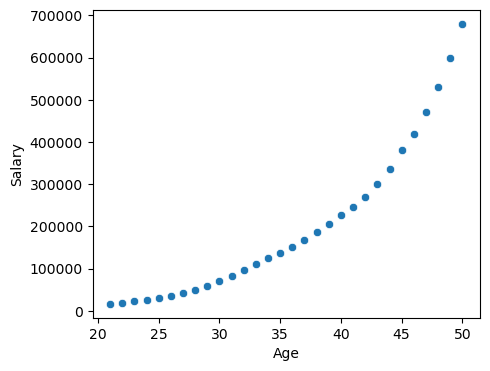

In [4]:
plt.figure(figsize=(5,4))

sns.scatterplot(x='Age', y='Salary', data=df)
plt.show()


In [8]:
# train test split

from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]
y = df['Salary']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# import linear regression first 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

linearModel = LinearRegression()

linearModel.fit(X_train, y_train)

y_pred = linearModel.predict(X_test)


print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))
print('R2 Score: ', r2_score(y_test, y_pred))




Mean Squared Error:  585583207.0882858
R2 Score:  0.9784616154096613


In [13]:
# prediction

linearModel.predict([[25, 2]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([16014.52164321])

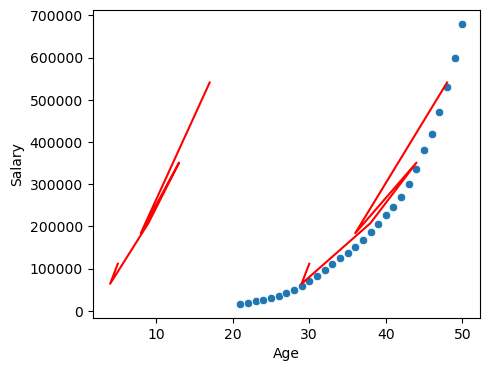

In [16]:
# graph between prediction and actual value

plt.figure(figsize=(5,4))

sns.scatterplot(x='Age', y='Salary', data=df)


plt.plot(X_test, y_pred, color='red')
plt.show()

In [63]:
# now using polynomial regression

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


# print(f"{X_train}")
# print(f"{X_train_poly}")

# getting feature names
print(f"{poly.get_feature_names_out()}")

linearModel = LinearRegression()

linearModel.fit(X_train_poly, y_train)

y_pred_new = linearModel.predict(X_test_poly)

print('Mean Squared Error: ', mean_squared_error(y_test, y_pred_new))
print('R2 Score: ', r2_score(y_test, y_pred))


# intercept and coefficients

print(linearModel.intercept_)
print(linearModel.coef_)

['1' 'Age' 'Experience' 'Age^2' 'Age Experience' 'Experience^2']
Mean Squared Error:  8813825.681009805
R2 Score:  0.9996758179453715
1298398.2920193505
[      0.         -126737.01073411  217105.10825393    3127.68853234
  -10608.72560997   10660.40979056]


In [65]:
# prediction

linearModel.predict(poly.transform([[21, 0]]))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([16231.70936668])

X_new shape: (100, 2)
X_new_poly shape: (100, 6)
y_new shape: (100,)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


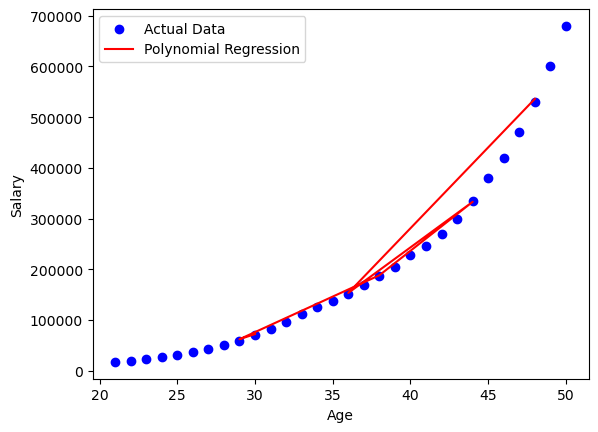

In [64]:
plt.scatter(df['Age'], df['Salary'], color='blue', label='Actual Data')
plt.plot(X_test.iloc[:, 0], y_pred_new, color='red', label='Polynomial Regression')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.show()
